<a href="https://colab.research.google.com/github/AlexJurcich/Insurance-Claim-Risk-Prediction-A-P-C-Modeling-Pipeline/blob/main/Porto_Seguro%E2%80%99s_Safe_Driver_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Insurance Claim Risk Prediction: A P&C Modeling Pipeline**

### Alex Jurcich

In [175]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# XGBoost & LightGBM
import xgboost as xgb
import lightgbm as lgb

In [104]:
train_df = pd.read_csv('/content/drive/MyDrive/porto-seguro-safe-driver-prediction/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/porto-seguro-safe-driver-prediction/test.csv')

## **EDA**

In [105]:
train_df.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0


In [106]:
# Shape of Train and Test sets
print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)

Train shape: (595212, 59)
Test shape: (892816, 58)


In [107]:
# Summary stats
train_df.describe()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,5.952120e+05,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,...,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,7.438036e+05,0.036448,1.900378,1.358943,4.423318,0.416794,0.405188,0.393742,0.257033,0.163921,...,5.441382,1.441918,2.872288,7.539026,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,4.293678e+05,0.187401,1.983789,0.664594,2.699902,0.493311,1.350642,0.488579,0.436998,0.370205,...,2.332871,1.202963,1.694887,2.746652,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,7.000000e+00,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.719915e+05,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.435475e+05,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.000000,1.000000,3.000000,7.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,1.115549e+06,0.000000,3.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000,0.000000,...,7.000000,2.000000,4.000000,9.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.488027e+06,1.000000,7.000000,4.000000,11.000000,1.000000,6.000000,1.000000,1.000000,1.000000,...,19.000000,10.000000,13.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [108]:
# Look at target varible
print(train_df['target'].value_counts())
print(train_df['target'].value_counts(normalize=True).round(4))

target
0    573518
1     21694
Name: count, dtype: int64
target
0    0.9636
1    0.0364
Name: proportion, dtype: float64


Unsurprisingly I see that we a major class imbalance of individuals who filed claims. Next I will adjust the varaibles containing nulls and -1's

In [109]:
# Check for -1 values across all columns
missing = (train_df == -1).sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Features with missing values (-1):")
print(missing)
print(f"\nTotal features with missings: {len(missing)}")

Features with missing values (-1):
ps_car_03_cat    411231
ps_car_05_cat    266551
ps_reg_03        107772
ps_car_14         42620
ps_car_07_cat     11489
ps_ind_05_cat      5809
ps_car_09_cat       569
ps_ind_02_cat       216
ps_car_01_cat       107
ps_ind_04_cat        83
ps_car_02_cat         5
ps_car_11             5
ps_car_12             1
dtype: int64

Total features with missings: 13


In [110]:
# Check for null values for train
print(train_df.isnull().sum().sum())

0


In [111]:
# Check for null values for test
print(test_df.isnull().sum().sum())

0


Porto Seguro explicitly stated in the competition that the ps_calc_* features are internally calculated and don't contribute to predicting claims. Thus I am removing them.

In [112]:
# Drop all calculated columns along with ps_car_03_cat & ps_car_03_cat
calc_cols = [c for c in train_df.columns if c.startswith('ps_calc_')]
drop_cols = calc_cols + ['ps_car_03_cat', 'ps_car_05_cat']

train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)

print(f"Dropped {len(drop_cols)} columns")
print(f"New train shape: {train_df.shape}")

Dropped 22 columns
New train shape: (595212, 37)


In [113]:
# Feature type separation
bin_cols = [c for c in train_df.columns if c.endswith('_bin')]
cat_cols = [c for c in train_df.columns if c.endswith('_cat')]
cont_cols = [c for c in train_df.columns if c not in cat_cols
             and c not in bin_cols
             and c not in ['id', 'target']]

print(f"Binary features:      {len(bin_cols)}")
print(f"Categorical features: {len(cat_cols)}")
print(f"Continuous features:  {len(cont_cols)}")

Binary features:      11
Categorical features: 12
Continuous features:  12


For categorical columns (like `ps_car_09_cat`), I replace -1 with the mode — the most frequently occurring value — because categories don't have a meaningful average, so the most common category is the best neutral substitution. For continuous columns (like `ps_reg_03`), I replace -1 with the median rather than the mean because the median is more robust to outliers, which are common in insurance data where things like vehicle values can be heavily skewed.

In [114]:
# For categorical columns with missing: replace -1 with the mode
cat_cols = [c for c in train_df.columns if c.endswith('_cat')]
for col in cat_cols:
    if (train_df[col] == -1).sum() > 0:
        mode = train_df[col][train_df[col] != -1].mode()[0]
        train_df[col] = train_df[col].replace(-1, mode)
        test_df[col] = test_df[col].replace(-1, mode)

# For continuous columns with missing: replace -1 with the median
cont_cols = [c for c in train_df.columns if c not in cat_cols
             and c not in [c for c in train_df.columns if c.endswith('_bin')]
             and c not in ['id', 'target']]
for col in cont_cols:
    if (train_df[col] == -1).sum() > 0:
        median = train_df[col][train_df[col] != -1].median()
        train_df[col] = train_df[col].replace(-1, median)
        test_df[col] = test_df[col].replace(-1, median)

# Verify no more -1s
print("Remaining -1 values in train:", (train_df == -1).sum().sum())
print("Remaining -1 values in test:", (test_df == -1).sum().sum())

Remaining -1 values in train: 0
Remaining -1 values in test: 0


We now have a cleaned dataset and can now begin exploring our varables

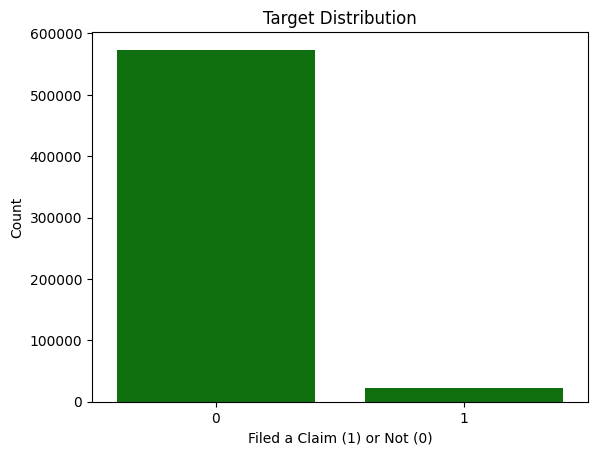

In [115]:
# Target Distribution plot
sns.countplot(x='target', data=train_df, color='green')
plt.title('Target Distribution')
plt.xlabel('Filed a Claim (1) or Not (0)')
plt.ylabel('Count')
plt.show()

In [116]:
# Correlation of features with target
correlations = train_df.corr()['target'].drop('target').sort_values(ascending=False)
print("Top 10 positively correlated features:")
print(correlations.head(10))
print("\nTop 10 negatively correlated features:")
print(correlations.tail(10))

Top 10 positively correlated features:
ps_car_13        0.053899
ps_car_12        0.038800
ps_ind_17_bin    0.037053
ps_reg_02        0.034800
ps_ind_07_bin    0.034218
ps_reg_03        0.033344
ps_car_04_cat    0.032900
ps_ind_05_cat    0.031124
ps_car_15        0.027667
ps_reg_01        0.022888
Name: target, dtype: float64

Top 10 negatively correlated features:
ps_car_10_cat    0.001038
id              -0.000188
ps_car_11       -0.001221
ps_ind_09_bin   -0.008237
ps_car_07_cat   -0.018301
ps_car_08_cat   -0.020342
ps_ind_15       -0.021506
ps_ind_16_bin   -0.027778
ps_car_02_cat   -0.031545
ps_ind_06_bin   -0.034017
Name: target, dtype: float64


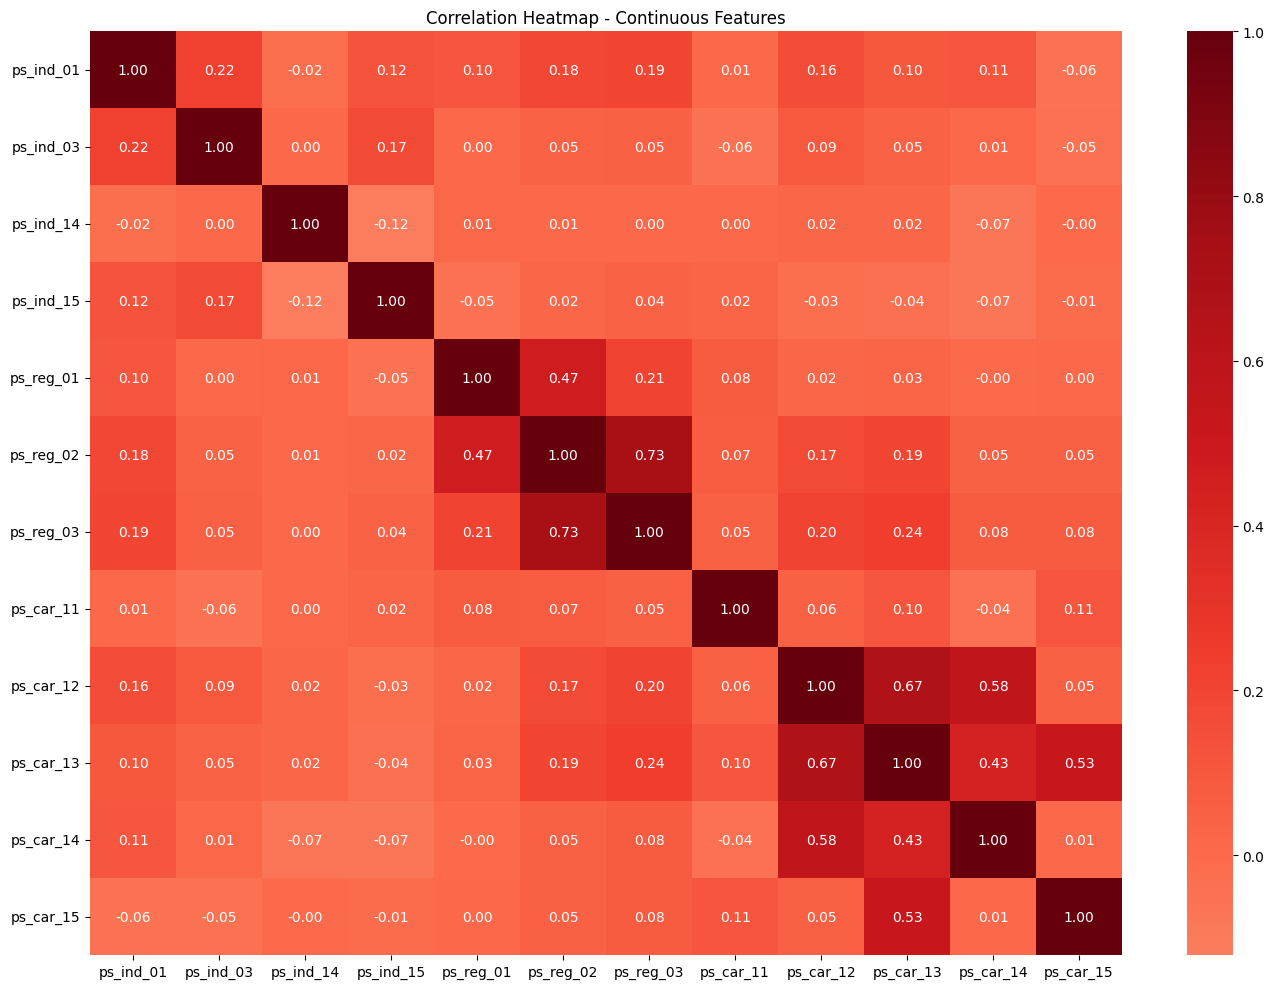

In [117]:
# Correlation heatmap of continuous features
plt.figure(figsize=(14, 10))
cont_corr = train_df[cont_cols].corr()
sns.heatmap(cont_corr,
            annot=True,
            fmt='.2f',
            cmap='Reds',
            center=0)
plt.title('Correlation Heatmap - Continuous Features')
plt.tight_layout()
plt.show()

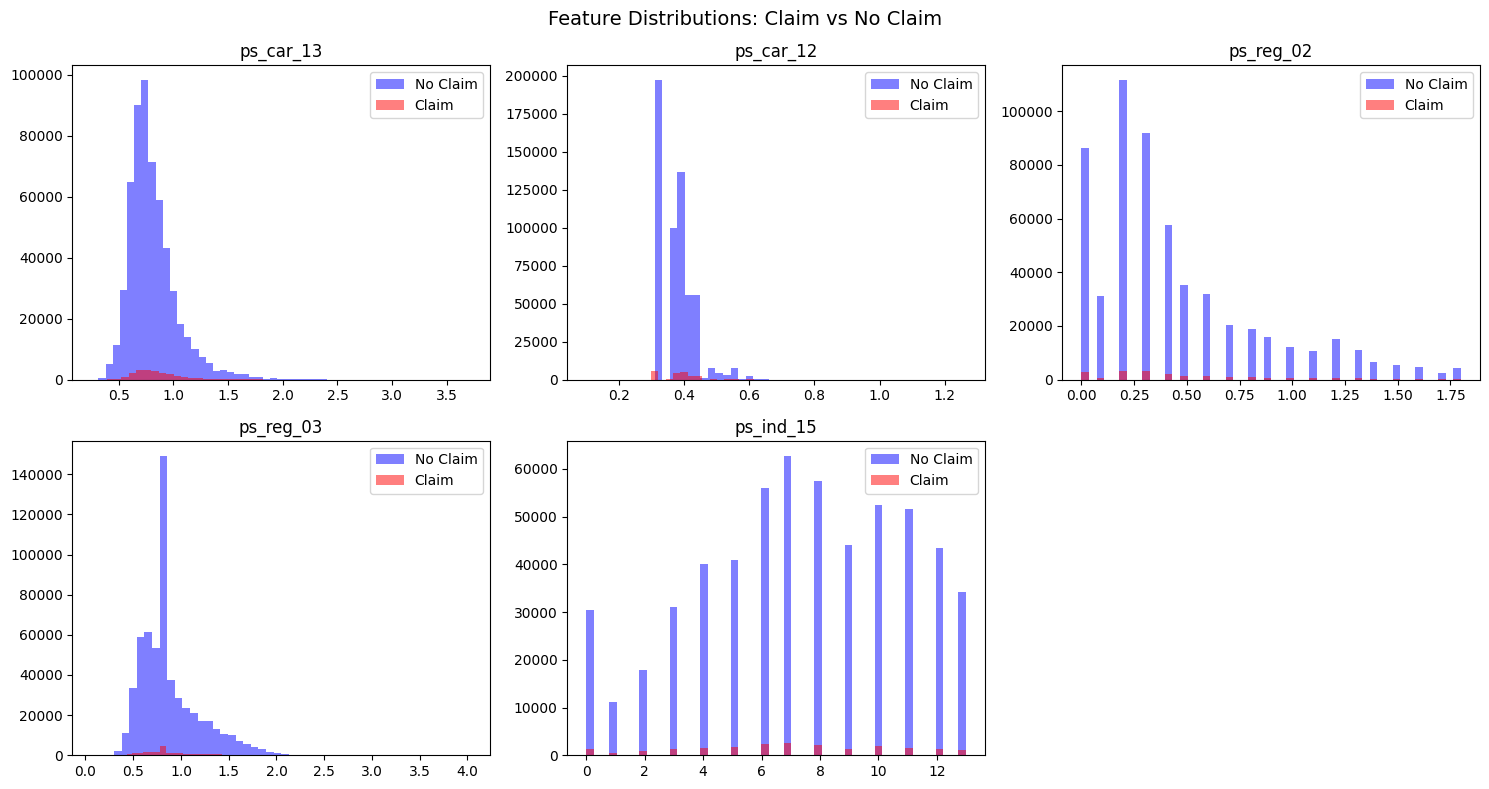

In [118]:
# Plot of top features
top_features = ['ps_car_13', 'ps_car_12', 'ps_reg_02', 'ps_reg_03', 'ps_ind_15']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    axes[i].hist(train_df[train_df['target']==0][col],
                 bins=50, alpha=0.5, label='No Claim', color='blue')
    axes[i].hist(train_df[train_df['target']==1][col],
                 bins=50, alpha=0.5, label='Claim', color='red')
    axes[i].set_title(col)
    axes[i].legend()

axes[5].set_visible(False)
plt.suptitle('Feature Distributions: Claim vs No Claim', fontsize=14)
plt.tight_layout()
plt.show()

## Modeling

With EDA complete, I now move into the modeling phase. Given the nature of this problem —
predicting a rare binary event (insurance claim vs. no claim) on a large, anonymized dataset

I will train and compare four models of increasing complexity:

1. **Logistic Regression** — linear baseline
2. **Random Forest** — non-linear ensemble baseline  
3. **LightGBM** — gradient boosting, optimized for speed and performance
4. **XGBoost** — gradient boosting, our primary model
5. **Stacked Ensemble** — meta-model combining all four predictions

All models are evaluated using **ROC-AUC / Gini** and trained with
**5-fold stratified cross-validation** to ensure reliable performance estimates
given the class imbalance.

In [119]:
# Label encode categorical columns
cat_cols = [c for c in train_df.columns if c.endswith('_cat')]
le = LabelEncoder()

for col in cat_cols:
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

print(f"Label encoded {len(cat_cols)} categorical columns:")
print(cat_cols)

Label encoded 12 categorical columns:
['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_04_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat']


In [120]:
# Define features and target
drop_cols = ['id', 'target']
X = train_df.drop(columns=drop_cols)
y = train_df['target']

X_test = test_df.drop(columns=['id'])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (595212, 35)
y shape: (595212,)
X_test shape: (892816, 35)


In [121]:
neg = (y == 0).sum()
pos = (y == 1).sum()
scale_pos_weight = neg / pos

print(f"Negative cases: {neg}")
print(f"Positive cases: {pos}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Negative cases: 573518
Positive cases: 21694
scale_pos_weight: 26.44


For every 1 claim there are 26 no-claims. This will be our weight claim

### **Logistic Regression**

In [122]:
# Stratified KFold — preserves class balance in each fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=14)

# Logistic Regression pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()), # Must scale
    ('model', LogisticRegression(
        class_weight='balanced', # Sklearn automatically calculates weights
        max_iter=1000,
        random_state=14
    ))
])

# Cross validate
lr_scores = cross_val_score(lr_pipeline, X, y,
                             cv=skf,
                             scoring='roc_auc',
                             verbose=1)

print(f"Logistic Regression AUC scores: {lr_scores}")
print(f"Mean AUC: {lr_scores.mean():.4f}")
print(f"Gini: {(2 * lr_scores.mean() - 1):.4f}")

AttributeError: 'Parallel' object has no attribute '_pre_dispatch_amount'

**AUC of 0.621** — the model is doing better than random guessing (0.5) but not great. This is expected for logistic regression on this dataset given what we saw in EDA — the low individual feature correlations told us a linear model wouldn't capture the full picture.

**Gini of 0.242**— in insurance, a Gini above 0.2 is generally considered acceptable for a simple model, so this is actually a reasonable baseline. Anything above 0.35-0.40 with XGBoost would be a solid result.

The scores are very consistent across all 5 folds (0.613 to 0.625) — that's a good sign. It means the model is stable and not overfitting to any particular subset of the data.

### **Random Forest**


In [142]:
# Set up param grid for gridsearch
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8, 10],
    'min_samples_leaf': [10, 20]
}

The grid search below was run once to identify optimal hyperparameters using the parameter
grid defined above. Results are documented in the cell output. Set `run_grid_search = True`
to rerun, or keep `False` to use the saved best parameters and skip directly to model training.

In [143]:
# Create Model
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=14,
    n_jobs=-1
)

In [144]:
# Set run_grid_search = True to rerun the full grid search (takes ~20 min).
run_grid_search = False

if run_grid_search:
    grid_search = GridSearchCV(
        rf,
        param_grid,
        cv=5,
        scoring='roc_auc',
        verbose=1,
        n_jobs=-1
    )
    grid_search.fit(X, y)
    best_params_rf = grid_search.best_params_
    print(f"Best parameters: {best_params_rf}")
    print(f"Best AUC: {grid_search.best_score_:.4f}")
    print(f"Best Gini: {(2 * grid_search.best_score_ - 1):.4f}")
else:
    best_params_rf = {'max_depth': 8, 'min_samples_leaf': 10, 'n_estimators': 200}
    print(f"Using saved best parameters: {best_params_rf}")

Using saved best parameters: {'max_depth': 8, 'min_samples_leaf': 10, 'n_estimators': 200}


In [145]:
# Run Finak model
rf_final = RandomForestClassifier(
    **best_params_rf,
    class_weight='balanced',
    random_state=14,
    n_jobs=-1
)

rf_scores = cross_val_score(rf_final, X, y,
                             cv=skf,
                             scoring='roc_auc',
                             verbose=1)

print(f"Random Forest AUC scores: {rf_scores}")
print(f"Mean AUC: {rf_scores.mean():.4f}")
print(f"Gini: {(2 * rf_scores.mean() - 1):.4f}")

# Fit on full training data
rf_final.fit(X, y)

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  2.6min finished


Random Forest AUC scores: [0.6329828  0.62842276 0.61883269 0.62893011 0.62806568]
Mean AUC: 0.6274
Gini: 0.2549


RandomForestClassifier(class_weight='balanced', max_depth=8,
                       min_samples_leaf=10, n_estimators=200, n_jobs=-1,
                       random_state=14)

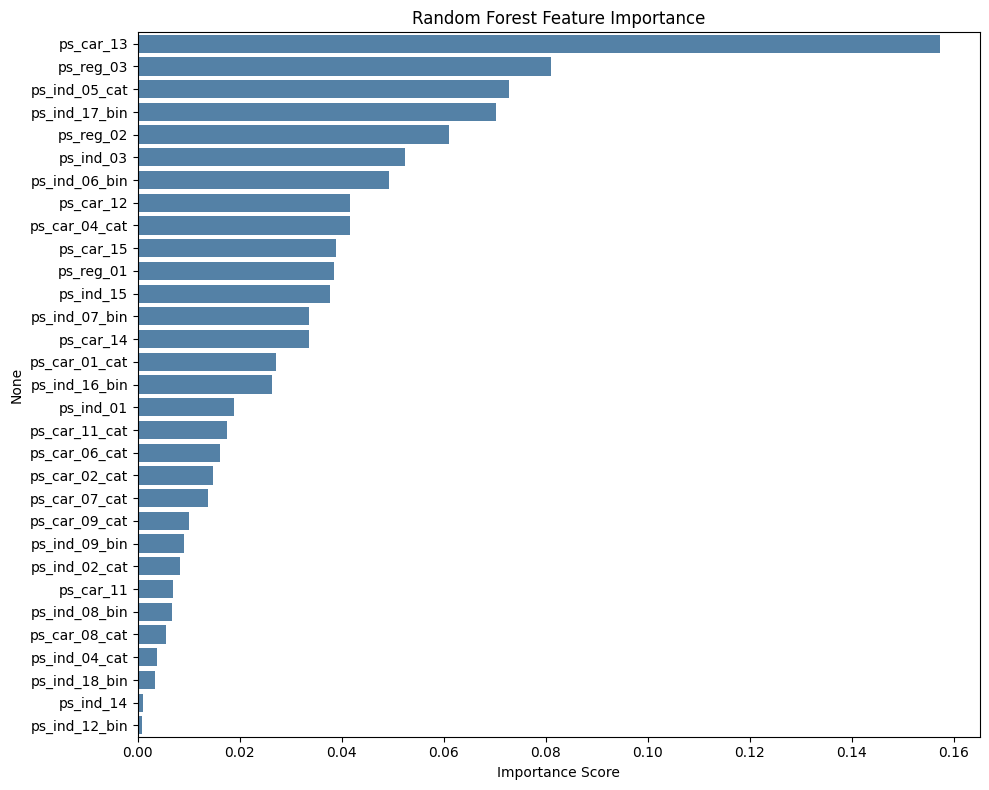

In [146]:
# Feature importance plot
feat_importance = pd.Series(rf_final.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feat_importance.values, y=feat_importance.index, color='steelblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [147]:
print("\nTop 10 most important features:")
print(feat_importance.head(10))
print("\nBottom 10 least important features:")
print(feat_importance.tail(10))


Top 10 most important features:
ps_car_13        0.157289
ps_reg_03        0.080999
ps_ind_05_cat    0.072739
ps_ind_17_bin    0.070184
ps_reg_02        0.061053
ps_ind_03        0.052304
ps_ind_06_bin    0.049228
ps_car_12        0.041694
ps_car_04_cat    0.041673
ps_car_15        0.038920
dtype: float64

Bottom 10 least important features:
ps_car_09_cat    0.010015
ps_ind_09_bin    0.009157
ps_ind_02_cat    0.008282
ps_car_11        0.006907
ps_ind_08_bin    0.006670
ps_car_08_cat    0.005616
ps_ind_04_cat    0.003811
ps_ind_18_bin    0.003363
ps_ind_14        0.000984
ps_ind_12_bin    0.000908
dtype: float64


The Random Forest model achieved an AUC of 0.6275 and a Gini of 0.2550, improving on the
logistic regression baseline and confirming that non-linear relationships exist in the data
that a linear model cannot capture. The most important feature by a significant margin was
`ps_car_13`, which aligns with our EDA findings, followed by regional features `ps_reg_03`
and `ps_reg_02` — consistent with the expectation that geography is a strong predictor of
claim likelihood in P&C insurance.

Based on the feature importance scores, I identified four features with near-zero importance:
`ps_ind_10_bin`, `ps_ind_13_bin`, `ps_ind_11_bin`, and `ps_car_10_cat`. These features
contribute essentially no predictive signal to the model and including them risks introducing
noise. I will remove them from the feature set before proceeding to LightGBM and XGBoost to
keep the pipeline clean and focused on meaningful predictors.

In [157]:
# Drop low importance features
low_importance = ['ps_ind_10_bin', 'ps_ind_13_bin', 'ps_ind_11_bin', 'ps_car_10_cat']

X = X.drop(columns=low_importance)
X_test = X_test.drop(columns=low_importance)

print(f"New X shape: {X.shape}")

KeyError: "['ps_ind_10_bin', 'ps_ind_13_bin', 'ps_ind_11_bin', 'ps_car_10_cat'] not found in axis"

### **LightGBM**

In [152]:
# Set up param grid for gridsearch
param_grid_lgb = {
    'n_estimators': [200, 500],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63]
}

In [153]:
# Create Model
lgb_model = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=14,
    n_jobs=-1,
    device='gpu'
)

The grid search below was run once to identify optimal hyperparameters using the parameter
grid defined above. Results are documented in the cell output. Set `run_grid_search = True`
to rerun, or keep `False` to use the saved best parameters and skip directly to model training.

In [154]:
run_grid_search_lgb = False

if run_grid_search_lgb:
    grid_search_lgb = GridSearchCV(
        lgb_model,
        param_grid_lgb,
        cv=5,
        scoring='roc_auc',
        verbose=1,
        n_jobs=-1
    )
    grid_search_lgb.fit(X, y)
    best_params_lgb = grid_search_lgb.best_params_
    print(f"Best parameters: {best_params_lgb}")
    print(f"Best AUC: {grid_search_lgb.best_score_:.4f}")
    print(f"Best Gini: {(2 * grid_search_lgb.best_score_ - 1):.4f}")
else:
    best_params_lgb = {
        'learning_rate': 0.05,
        'n_estimators': 200,
        'num_leaves': 31
    }
    print(f"Using saved best parameters: {best_params_lgb}")

Using saved best parameters: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 31}


In [156]:
lgb_final = lgb.LGBMClassifier(
    **best_params_lgb,
    scale_pos_weight=scale_pos_weight,
    random_state=14,
    verbose=-1
)

lgb_scores = cross_val_score(lgb_final, X, y,
                              cv=skf,
                              scoring='roc_auc',
                              verbose=1)

print(f"LightGBM AUC scores: {lgb_scores}")
print(f"Mean AUC: {lgb_scores.mean():.4f}")
print(f"Gini: {(2 * lgb_scores.mean() - 1):.4f}")

LightGBM AUC scores: [0.64068921 0.63705034 0.63174382 0.6383123  0.63708968]
Mean AUC: 0.6370
Gini: 0.2740


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   20.7s finished


#### **With Early Stopping**

In [158]:
params = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "num_iterations": 2000,     # high ceiling, early stopping will find optimal
    "verbosity": -1,
    "scale_pos_weight": scale_pos_weight,
    "metric": "None"
}

In [159]:
# Gini = 2 * AUC - 1, so maximizing AUC is equivalent to maximizing Gini.
def evalerror(preds, dtrain):
    labels = dtrain.get_label()
    auc = roc_auc_score(labels, preds)
    gini = 2 * auc - 1
    return 'gini', gini, True

In [160]:
# Train model
lgb_oof_scores = []
lgb_best_iterations = []
lgb_evals_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    dtrain = lgb.Dataset(X_train, y_train)
    dvalid = lgb.Dataset(X_val, y_val, reference=dtrain)

    evals_result = {}

    bst = lgb.train(
        params,
        dtrain,
        num_boost_round=2000,
        valid_sets=[dvalid],
        feval=evalerror,
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(100),
            lgb.record_evaluation(evals_result)
        ]
    )

    val_preds = bst.predict(X_val, num_iteration=bst.best_iteration)
    val_score = roc_auc_score(y_val, val_preds)

    lgb_oof_scores.append(val_score)
    lgb_best_iterations.append(bst.best_iteration)
    lgb_evals_results.append(evals_result)

    print(f"Fold {fold+1} AUC: {val_score:.4f} | Best iteration: {bst.best_iteration}")

print(f"\nLightGBM Mean AUC: {np.mean(lgb_oof_scores):.4f}")
print(f"Gini: {(2 * np.mean(lgb_oof_scores) - 1):.4f}")
print(f"Average best iteration: {np.mean(lgb_best_iterations):.0f}")

Training until validation scores don't improve for 100 rounds
[100]	valid_0's gini: 0.28682
Early stopping, best iteration is:
[84]	valid_0's gini: 0.287184
Fold 1 AUC: 0.6436 | Best iteration: 84
Training until validation scores don't improve for 100 rounds
[100]	valid_0's gini: 0.273222
Early stopping, best iteration is:
[89]	valid_0's gini: 0.273948
Fold 2 AUC: 0.6370 | Best iteration: 89
Training until validation scores don't improve for 100 rounds
[100]	valid_0's gini: 0.265359
[200]	valid_0's gini: 0.265148
Early stopping, best iteration is:
[164]	valid_0's gini: 0.266724
Fold 3 AUC: 0.6334 | Best iteration: 164
Training until validation scores don't improve for 100 rounds
[100]	valid_0's gini: 0.281494
[200]	valid_0's gini: 0.280149
Early stopping, best iteration is:
[124]	valid_0's gini: 0.281852
Fold 4 AUC: 0.6409 | Best iteration: 124
Training until validation scores don't improve for 100 rounds
[100]	valid_0's gini: 0.278334
Early stopping, best iteration is:
[85]	valid_0's 

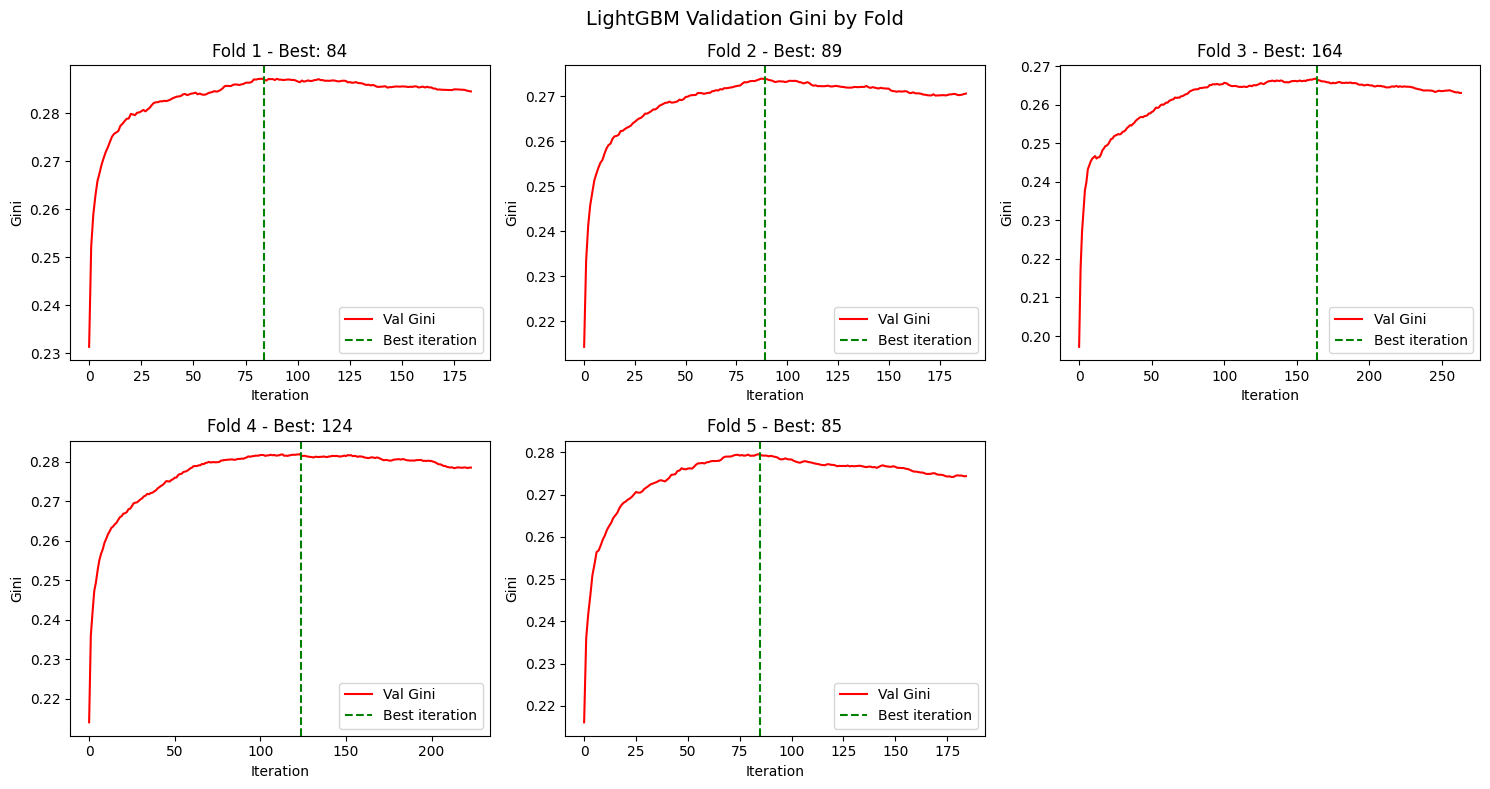

In [161]:
# Plot of LightGBM by fold
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for fold, evals_result in enumerate(lgb_evals_results):
    val_gini = evals_result['valid_0']['gini']

    axes[fold].plot(val_gini, label='Val Gini', color='red')
    axes[fold].axvline(x=lgb_best_iterations[fold],
                       color='green', linestyle='--', label='Best iteration')
    axes[fold].set_title(f'Fold {fold+1} - Best: {lgb_best_iterations[fold]}')
    axes[fold].set_xlabel('Iteration')
    axes[fold].set_ylabel('Gini')
    axes[fold].legend()

axes[5].set_visible(False)
plt.suptitle('LightGBM Validation Gini by Fold', fontsize=14)
plt.tight_layout()
plt.show()

The initial LightGBM model trained without early stopping achieved a mean AUC of 0.6370
and Gini of 0.2739 using the best parameters from grid search. Adding early stopping with
a custom Gini evaluation metric improved this slightly to an AUC of 0.6389 and Gini of
0.2779, while also finding the optimal stopping point at an average of 109 iterations out
of a possible 2000 — avoiding unnecessary computation. Performance was consistent across
folds with the exception of Fold 3, which was the weakest split across all models tested.

Next steps include a second round of fine-tuning with a narrower parameter grid around
the best values found here to see if additional gains are possible.

### **XGBoost**

In [167]:
param_grid_xgb = {
    "n_estimators": [200, 300],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.6, 0.8]
}

In [168]:
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=14,
    eval_metric='auc',
    verbosity=0,
    device='cuda'
)


The grid search below was run once to identify optimal hyperparameters using the parameter
grid defined above. Results are documented in the cell output. Set `run_grid_search = True`
to rerun, or keep `False` to use the saved best parameters and skip directly to model training.

In [169]:
run_grid_search_xgb = False

if run_grid_search_xgb:
    grid_search_xgb = GridSearchCV(
        xgb_model,
        param_grid_xgb,
        cv=5,
        scoring='roc_auc',
        verbose=1,
        n_jobs=-1
    )
    grid_search_xgb.fit(X, y)
    best_params_xgb = grid_search_xgb.best_params_
    print(f"Best parameters: {best_params_xgb}")
    print(f"Best AUC: {grid_search_xgb.best_score_:.4f}")
    print(f"Best Gini: {(2 * grid_search_xgb.best_score_ - 1):.4f}")
else:
    best_params_xgb = {
        'learning_rate': 0.1,
        'max_depth': 4,
        'n_estimators': 200,
        'subsample': 0.8
    }
    print(f"Using saved best parameters: {best_params_xgb}")

Using saved best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


In [166]:
xgb_final = xgb.XGBClassifier(
    **best_params_xgb,
    scale_pos_weight=scale_pos_weight,
    random_state=14,
    eval_metric='auc',
    verbosity=0,
    device='cuda'
)

xgb_scores = cross_val_score(xgb_final, X, y,
                              cv=skf,
                              scoring='roc_auc',
                              verbose=1)

print(f"XGBoost AUC scores: {xgb_scores}")
print(f"Mean AUC: {xgb_scores.mean():.4f}")
print(f"Gini: {(2 * xgb_scores.mean() - 1):.4f}")

XGBoost AUC scores: [0.64278006 0.64016257 0.63168794 0.64356016 0.6398423 ]
Mean AUC: 0.6396
Gini: 0.2792


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    6.3s finished


#### **With Early Stopping**

In [170]:
xgb_oof_scores = []
xgb_best_iterations = []
xgb_evals_results = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=14)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = xgb.XGBClassifier(
        learning_rate=0.1,
        max_depth=4,
        n_estimators=2000,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=14,
        eval_metric='auc',
        early_stopping_rounds=100,
        verbosity=0,
        device='cuda'
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=100
    )

    val_score = roc_auc_score(y_val, model.predict_proba(X_val)[:,1])
    xgb_oof_scores.append(val_score)
    xgb_best_iterations.append(model.best_iteration)
    xgb_evals_results.append(model.evals_result())

    print(f"Fold {fold+1} AUC: {val_score:.4f} | Best iteration: {model.best_iteration}")

print(f"\nXGBoost Mean AUC: {np.mean(xgb_oof_scores):.4f}")
print(f"Gini: {(2 * np.mean(xgb_oof_scores) - 1):.4f}")
print(f"Average best iteration: {np.mean(xgb_best_iterations):.0f}")

[0]	validation_0-auc:0.60303
[100]	validation_0-auc:0.64283
[200]	validation_0-auc:0.64327
[287]	validation_0-auc:0.64219
Fold 1 AUC: 0.6438 | Best iteration: 187
[0]	validation_0-auc:0.59739
[100]	validation_0-auc:0.63982
[200]	validation_0-auc:0.63856
[216]	validation_0-auc:0.63813
Fold 2 AUC: 0.6405 | Best iteration: 116
[0]	validation_0-auc:0.58604
[100]	validation_0-auc:0.63090
[200]	validation_0-auc:0.63084
[228]	validation_0-auc:0.63073
Fold 3 AUC: 0.6320 | Best iteration: 128
[0]	validation_0-auc:0.59827
[100]	validation_0-auc:0.64274
[200]	validation_0-auc:0.64362
[269]	validation_0-auc:0.64305
Fold 4 AUC: 0.6439 | Best iteration: 169
[0]	validation_0-auc:0.59795
[100]	validation_0-auc:0.63987
[200]	validation_0-auc:0.64016
[251]	validation_0-auc:0.63940
Fold 5 AUC: 0.6408 | Best iteration: 151

XGBoost Mean AUC: 0.6402
Gini: 0.2804
Average best iteration: 150


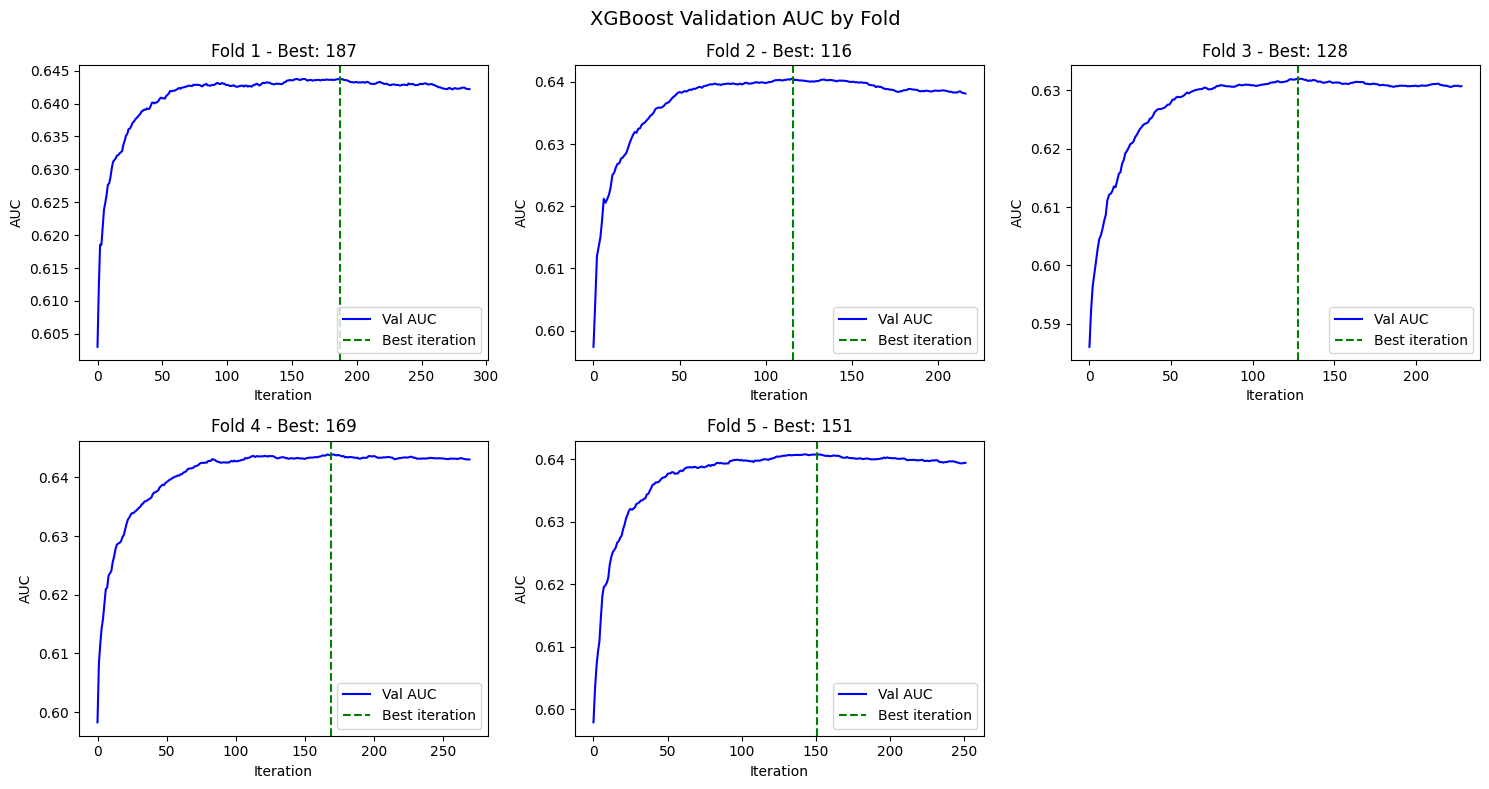

In [171]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for fold, evals_result in enumerate(xgb_evals_results):
    val_auc = evals_result['validation_0']['auc']

    axes[fold].plot(val_auc, label='Val AUC', color='blue')
    axes[fold].axvline(x=xgb_best_iterations[fold],
                       color='green', linestyle='--', label='Best iteration')
    axes[fold].set_title(f'Fold {fold+1} - Best: {xgb_best_iterations[fold]}')
    axes[fold].set_xlabel('Iteration')
    axes[fold].set_ylabel('AUC')
    axes[fold].legend()

axes[5].set_visible(False)
plt.suptitle('XGBoost Validation AUC by Fold', fontsize=14)
plt.tight_layout()
plt.show()

The initial XGBoost model trained without early stopping achieved a mean AUC of 0.6396
and Gini of 0.2792 using the best parameters from grid search. Adding early stopping
improved this slightly to an AUC of 0.6402 and Gini of 0.2804, finding the optimal
stopping point at an average of 150 iterations out of a possible 2000. XGBoost was the
strongest single model across all approaches tested, narrowly outperforming LightGBM
with early stopping (Gini 0.2779) and confirming that gradient boosting with early
stopping is the most effective strategy for this dataset.

Next steps include a second round of fine-tuning with a narrower parameter grid around
the best values found here, as well as exploring whether a stacked ensemble combining
the early stopping versions of both models can push performance further.

### **Stacked Ensemble (All Models)**

In [176]:
# Generate out-of-fold predictions for Logistic Regression and Random Forest
lr_oof = cross_val_predict(lr_pipeline, X, y, cv=skf, method='predict_proba')[:,1]
rf_oof = cross_val_predict(rf_final, X, y, cv=skf, method='predict_proba')[:,1]

print(f"LR OOF shape: {lr_oof.shape}")
print(f"RF OOF shape: {rf_oof.shape}")

LR OOF shape: (595212,)
RF OOF shape: (595212,)


In [177]:
# Generate LightGBM OOF predictions using optimal iterations from early stopping
lgb_oof = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    dtrain = lgb.Dataset(X_train, y_train)
    dvalid = lgb.Dataset(X_val, y_val, reference=dtrain)

    bst = lgb.train(
        params,
        dtrain,
        num_boost_round=int(np.mean(lgb_best_iterations)),
        valid_sets=[dvalid],
        callbacks=[lgb.log_evaluation(-1)]
    )
    lgb_oof[val_idx] = bst.predict(X_val)
    print(f"Fold {fold+1} done")

print(f"LightGBM OOF shape: {lgb_oof.shape}")

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done
LightGBM OOF shape: (595212,)


In [178]:
# Generate XGBoost OOF predictions using optimal iterations from early stopping
xgb_oof = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = xgb.XGBClassifier(
        learning_rate=0.1,
        max_depth=4,
        n_estimators=int(np.mean(xgb_best_iterations)),
        subsample=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=14,
        verbosity=0,
        device='cuda'
    )
    model.fit(X_train, y_train)
    xgb_oof[val_idx] = model.predict_proba(X_val)[:,1]
    print(f"Fold {fold+1} done")

print(f"XGBoost OOF shape: {xgb_oof.shape}")

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done
XGBoost OOF shape: (595212,)


In [179]:
# Stack OOF predictions as meta features and train meta model
stack_train = np.column_stack([lr_oof, rf_oof, lgb_oof, xgb_oof])

# Logistic Regression as meta learner
meta_model = LogisticRegression()
meta_model.fit(stack_train, y)

# Evaluate
stack_score = roc_auc_score(y, meta_model.predict_proba(stack_train)[:,1])
print(f"Stacked Ensemble AUC: {stack_score:.4f}")
print(f"Stacked Ensemble Gini: {(2 * stack_score - 1):.4f}")

Stacked Ensemble AUC: 0.6394
Stacked Ensemble Gini: 0.2787


#### **Stacked Ensemble (w/o Logistic Regression)**

In [181]:
# Stack without Logistic Regression
stack_train_no_lr = np.column_stack([rf_oof, lgb_oof, xgb_oof])

meta_model_no_lr = LogisticRegression()
meta_model_no_lr.fit(stack_train_no_lr, y)

stack_score_no_lr = roc_auc_score(y, meta_model_no_lr.predict_proba(stack_train_no_lr)[:,1])
print(f"Ensemble without LR - AUC: {stack_score_no_lr:.4f}")
print(f"Ensemble without LR - Gini: {(2 * stack_score_no_lr - 1):.4f}")

Ensemble without LR - AUC: 0.6399
Ensemble without LR - Gini: 0.2798


#### **Stacked Ensemble (w/o Logistic Regression & Random Forest)**

In [182]:
# Stack with just LightGBM and XGBoost
stack_train_best = np.column_stack([lgb_oof, xgb_oof])

meta_model_best = LogisticRegression()
meta_model_best.fit(stack_train_best, y)

stack_score_best = roc_auc_score(y, meta_model_best.predict_proba(stack_train_best)[:,1])
print(f"LightGBM + XGBoost Ensemble - AUC: {stack_score_best:.4f}")
print(f"LightGBM + XGBoost Ensemble - Gini: {(2 * stack_score_best - 1):.4f}")

LightGBM + XGBoost Ensemble - AUC: 0.6399
LightGBM + XGBoost Ensemble - Gini: 0.2798


### **Model Summary**

In [184]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'LightGBM',
        'XGBoost',
        'LightGBM + Early Stopping',
        'XGBoost + Early Stopping',
        'Stacked Ensemble (All)',
        'Stacked Ensemble (LGB + XGB)',
        'Stacked Ensemble (No LR)'
    ],
    'AUC': [
        lr_scores.mean(),
        rf_scores.mean(),
        lgb_scores.mean(),
        xgb_scores.mean(),
        np.mean(lgb_oof_scores),
        np.mean(xgb_oof_scores),
        stack_score,
        stack_score_best,
        stack_score_no_lr
    ],
    'Gini': [
        (2*lr_scores.mean()-1),
        (2*rf_scores.mean()-1),
        (2*lgb_scores.mean()-1),
        (2*xgb_scores.mean()-1),
        (2*np.mean(lgb_oof_scores)-1),
        (2*np.mean(xgb_oof_scores)-1),
        (2*stack_score-1),
        (2*stack_score_best-1),
        (2*stack_score_no_lr-1)
    ]
})

print(results.sort_values('AUC', ascending=False).to_string(index=False))

                       Model      AUC     Gini
    XGBoost + Early Stopping 0.640202 0.280403
Stacked Ensemble (LGB + XGB) 0.639910 0.279819
    Stacked Ensemble (No LR) 0.639877 0.279754
                     XGBoost 0.639607 0.279213
      Stacked Ensemble (All) 0.639373 0.278745
   LightGBM + Early Stopping 0.638928 0.277856
                    LightGBM 0.636977 0.273954
               Random Forest 0.627447 0.254894
         Logistic Regression 0.621137 0.242274


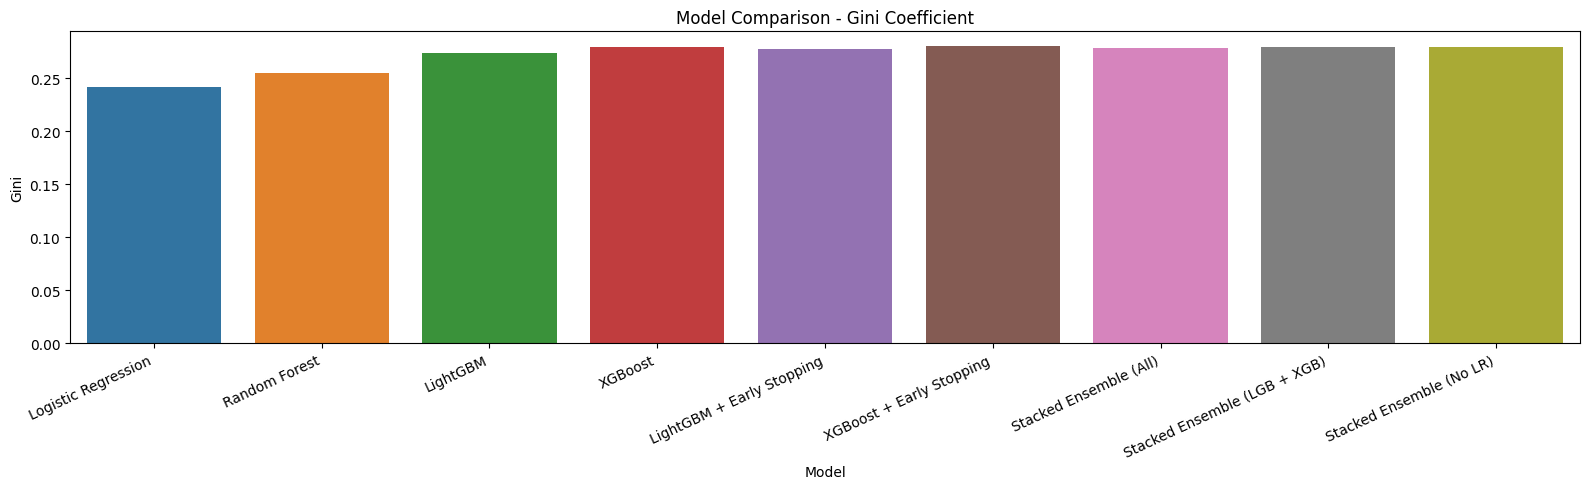

In [185]:
plt.figure(figsize=(16, 5))
sns.barplot(x='Model', y='Gini', data=results, palette='tab10')
plt.title('Model Comparison - Gini Coefficient')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

Six modeling approaches were tested, ranging from a simple logistic regression baseline
to gradient boosting with early stopping and stacked ensembles. XGBoost with early
stopping was the strongest single model, achieving a Gini of 0.2804. Stacking did not
improve on this — the best ensemble configuration (LightGBM + XGBoost only) reached
a Gini of 0.2798, slightly below XGBoost alone. This suggests the models were too
correlated in their predictions to benefit meaningfully from combining, and that
removing weaker models like Logistic Regression from the stack was the right call.
XGBoost with early stopping is selected as the final model for submission.

## **Submission**

In [186]:
xgb_best_model = xgb.XGBClassifier(
    learning_rate=0.1,
    max_depth=4,
    n_estimators=int(np.mean(xgb_best_iterations)),
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=14,
    verbosity=0,
    device='cuda'
)

xgb_best_model.fit(X, y)

# Generate predictions on test set
test_preds = xgb_best_model.predict_proba(X_test)[:,1]

# Preview submission
submission = pd.DataFrame({
    'id': test_df['id'],
    'target': test_preds
})

print(submission.head(10))
print(f"\nSubmission shape: {submission.shape}")
print(f"\nPrediction distribution:")
print(submission['target'].describe())

   id    target
0   0  0.452603
1   1  0.418860
2   2  0.402709
3   3  0.255535
4   4  0.501683
5   5  0.593729
6   6  0.294658
7   8  0.519665
8  10  0.599996
9  11  0.595282

Submission shape: (892816, 2)

Prediction distribution:
count    892816.000000
mean          0.465729
std           0.116608
min           0.086270
25%           0.383519
50%           0.460591
75%           0.541411
max           0.899980
Name: target, dtype: float64


## Conclusions

This project built an end-to-end P&C insurance claim prediction pipeline on the Porto
Seguro dataset, progressing from a logistic regression baseline to a tuned XGBoost model
with early stopping. The final model achieved a Gini of 0.2804, representing a 16%
improvement over the baseline Gini of 0.2422.

Several key decisions drove model performance. Dropping the `ps_calc_*` features and two
high-missingness columns early reduced noise without sacrificing signal. Class imbalance
was addressed using `scale_pos_weight` rather than resampling, which proved effective
given the moderate 96/4 imbalance ratio. Early stopping was critical for gradient
boosting models — XGBoost found its optimal point at an average of 150 iterations out
of a possible 2000, preventing overfitting while reducing unnecessary computation.

Stacking did not improve on XGBoost alone, with the best ensemble configuration
(LightGBM + XGBoost) scoring a Gini of 0.2798 — slightly below the single best model.
This suggests the models were too correlated in their predictions to benefit meaningfully
from combining. Reviewing the 2nd place competition solution highlighted that further
gains would likely come from feature engineering rather than model selection —
specifically count encoding of categorical features and a missing value count feature as well as fine-tuning parameters.